In [2]:
import earthaccess,csv
import xarray as xr
from xarray.backends.api import open_datatree
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy.ndimage import generic_filter
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata
from scipy.ndimage import median_filter
from scipy.interpolate import LinearNDInterpolator
from scipy.ndimage import generic_filter
from scipy.stats import binned_statistic_2d

In [3]:
import warnings
warnings.filterwarnings("ignore")

In [4]:
smoothing_factor=10 #smoothing factor of ug and vg for strain and vort

In [5]:
pip show jax

Name: jax
Version: 0.8.1
Summary: Differentiate, compile, and transform Numpy code.
Home-page: https://github.com/jax-ml/jax
Author: JAX team
Author-email: jax-dev@google.com
License: Apache-2.0
Location: /srv/conda/envs/notebook/lib/python3.11/site-packages
Requires: jaxlib, ml_dtypes, numpy, opt_einsum, scipy
Required-by: chex, jaxparrow, optax
Note: you may need to restart the kernel to use updated packages.


In [6]:
%pip install jaxparrow
from jaxparrow import cyclogeostrophy
from jaxparrow import geostrophy
import jax.numpy as jnp
import jaxparrow as jxr

Note: you may need to restart the kernel to use updated packages.


In [7]:
# conda install conda-forge::pyinterp

In [8]:
%conda install pyinterp

Channels:
 - conda-forge
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.0
    latest version: 25.11.0

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /srv/conda/envs/notebook

  added / updated specs:
    - pyinterp


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2025.11.12 |       hbd8a1cb_0         149 KB  conda-forge
    certifi-2025.11.12         |     pyhd8ed1ab_0         153 KB  conda-forge
    openblas-0.3.29            |pthreads_h6ec200e_0         5.8 MB  conda-forge
    openssl-3.6.0              |       h26f9b46_0         3.0 MB  conda-forge
    pyinterp-2025.8.1          |openblas_py311h7902aa3_102         4.5 MB  conda-forge
    ------------------------------------------------------------
               

In [9]:
%pip install widetrax

  Using cached widetrax-1.1.1-py3-none-any.whl.metadata (2.2 kB)
  Using cached datetime-6.0-py3-none-any.whl.metadata (34 kB)
  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached opencv_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached opencv_contrib_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (19 kB)
  Using cached zope_interface-8.1.1-cp311-cp311-manylinux1_x86_64.manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_5_x86_64.whl.metadata (45 kB)
  Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (62 kB)
Using cached widetrax-1.1.1-py3-none-any.whl (21 kB)
Using cached datetime-6.0-py3-none-any.whl (52 kB)
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
Using cached opencv_contrib_python-4.12.0.88-cp37-abi3-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (73.2 MB)
Using cached numpy-2.2.6-cp311-cp311-manylinux_2_17_x8

In [10]:
import widetrax
from widetrax import Spectra as sp
from widetrax import DataPreprocessing as dp
from widetrax import Grads as gr

In [11]:
%%bash
python --version

Python 3.11.11


In [12]:
date_requested = '20240508'
pacedate="2024-05-08"

In [13]:
aviso_ds = xr.open_dataset('data/eddy_trajectories/Edward_Eddy_trajectory_nrt_3.2exp_cyclonic_20180101_20240723.nc')

In [14]:
dates = [i for i in aviso_ds.time.values] # these are sorted already
print(min(dates))
print(max(dates)) # still existed at the end of the dataset
tminny=str(min(dates))
tminny=tminny[0:10]
tmaxxy=str(max(dates))
tmaxxy=tmaxxy[0:10]
tmin,tmax = tminny,tmaxxy
center_lats = [i for i in aviso_ds.latitude.values]
center_lons = [i for i in aviso_ds.longitude.values]
print(len(center_lats))
print(min(center_lats))
print(max(center_lats))
print(min(center_lons)-360)
print(max(center_lons)-360)
#Define box based on eddy
latmin,latmax = min(center_lats)-2,max(center_lats)+2
lonmin,lonmax = min(center_lons)-360-2,max(center_lons)-360+2

2023-12-14T00:00:00.000000000
2024-07-23T00:00:00.000000000
223
35.502697
36.847385
-71.77411
-67.887146


In [15]:
def get_eddy_by_ID_date(ds,eddy_date):
    """
    ds: netCDF AVISO format
    track_id: id of eddy to extract
    eddy_date: date in format 'YYYY-MM-DD'

    Returns contour lons, contour lats, center lon, center lat
    """
    try:
        ind = np.where(ds.time == np.datetime64(eddy_date))[0][0]
        contour_lons = np.array(ds.effective_contour_longitude[ind])
        contour_lats = np.array(ds.effective_contour_latitude[ind])
    except:
        print('No eddy data available with that request ... :(')        
    
    return contour_lons,contour_lats,ds.longitude[ind],ds.latitude[ind]

In [16]:
contour_lons, contour_lats, _, _ = get_eddy_by_ID_date(aviso_ds, pacedate)

In [17]:
auth = earthaccess.login(persist=True)

In [18]:
def get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax):
    """
    Searches for SWOT data within the bounding box and time. Note that this doesn't work for unsmoothed data. 
    
    latmin,latmax: latitude bounds, degrees N (south is negative); floats
    lonmin, lonmax: longitude bounds, degrees E (west is negative); floats
    tmin,tmax: temporal bounds; strings of form 'yyyy-mm-dd'
    """
    bbox = (lonmin, latmin, lonmax, latmax) # lonW, latS, lonE, latN
    results = earthaccess.search_data(
        short_name="SWOT_L2_LR_SSH_EXPERT_2.0",
        bounding_box=bbox,
        temporal=(tmin,tmax))
    
    print("Number of swaths: " + str(len(results))) # not daily files, so will likely be more than # of days
    paths = earthaccess.open(results) # is there a way to choose a subset of variables here?

    return paths

In [19]:
eddy_paths = get_swot_data(latmin,latmax,lonmin,lonmax,tmin,tmax)

Number of swaths: 242


QUEUEING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/242 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/242 [00:00<?, ?it/s]

In [20]:
ind = 0 
for i in eddy_paths:
    today = str(i).split('-')[-1].split('_')[-4][0:8]
    if date_requested == today:
        print(ind)
        sel=ind
    ind += 1

166
167


In [21]:
ds1 = xr.open_dataset(eddy_paths[sel])
ds2 = xr.open_dataset(eddy_paths[sel-1])

In [22]:
def crop_dataset_by_lat_lon(ds,latmin,latmax,lonmin,lonmax):
    mask = (ds.latitude >= latmin) & (ds.latitude <= latmax) & (ds.longitude >= lonmin+360) & (ds.longitude <= lonmax+360)
    ds_masked = ds.where(mask, drop=True)
    return ds_masked

In [23]:
ds1_masked = crop_dataset_by_lat_lon(ds1,latmin,latmax,lonmin,lonmax)
ds2_masked = crop_dataset_by_lat_lon(ds2,latmin,latmax,lonmin,lonmax)

In [24]:
ds=ds1_masked
ssh=ds.ssha_karin_2+ds.height_cor_xover
lats=ds.latitude
lons=ds.longitude
ds=ds.assign(ssha=ssh)

In [25]:
ds2=ds2_masked
ssh2=ds2.ssha_karin_2+ds2.height_cor_xover
lats2=ds2.latitude
lons2=ds2.longitude
ds2=ds2.assign(ssha=ssh2)

In [26]:
ug, vg, j, j1, j12, j3 = geostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
ug2, vg2, j, j1, j12, j3 = geostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2)) #they inversed this!

In [27]:
u_cyclo_2d, v_cyclo_2d, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh),jnp.array(lats),jnp.array(lons))
u_cyclo_2d_2, v_cyclo_2d_2, j, j1, j12, j3 =cyclogeostrophy(jnp.array(ssh2),jnp.array(lats2),jnp.array(lons2))

In [28]:
#Following function written with assistance of AI
def remove_swath_edges(data_array, edge_pixels):
    """
    Simple approach: remove edge pixels from all continuous non-NaN segments
    """
    result = jnp.array(data_array)
    n_rows, n_cols = data_array.shape
    
    for i in range(n_rows):
        # Convert to numpy for gap detection
        row_data = np.array(data_array[i, :])
        valid_mask = ~np.isnan(row_data)
        
        # Find where valid data starts and ends
        if np.any(valid_mask):
            # Find all valid segments
            diff = np.diff(valid_mask.astype(int))
            segment_starts = np.where(diff == 1)[0] + 1
            segment_ends = np.where(diff == -1)[0] + 1
            
            # Handle edge cases
            if valid_mask[0]:
                segment_starts = np.insert(segment_starts, 0, 0)
            if valid_mask[-1]:
                segment_ends = np.append(segment_ends, n_cols)
            
            # Remove edges from each segment
            for start, end in zip(segment_starts, segment_ends):
                if (end - start) > 2 * edge_pixels:
                    # Remove left edge
                    result = result.at[i, start:start + edge_pixels].set(jnp.nan)
                    # Remove right edge
                    result = result.at[i, end - edge_pixels:end].set(jnp.nan)
    
    return result

In [29]:
np.shape(ug)

(318, 69)

In [30]:
ds.num_pixels

<xarray.DataArray 'num_pixels' (num_pixels: 69)> Size: 552B
array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35,
       36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53,
       54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68])
Dimensions without coordinates: num_pixels

In [31]:
pixel_num=2 #This number will change per 
ug = remove_swath_edges(ug, edge_pixels=pixel_num)
ug2 = remove_swath_edges(ug2,edge_pixels=pixel_num)
vg = remove_swath_edges(vg,edge_pixels=pixel_num)
vg2 = remove_swath_edges(vg2,edge_pixels=pixel_num)

In [32]:
pixel_num=2 #This number will change per 
ucyclo = remove_swath_edges(u_cyclo_2d, edge_pixels=pixel_num)
ucyclo2 = remove_swath_edges(u_cyclo_2d_2, edge_pixels=pixel_num)
vcyclo = remove_swath_edges(v_cyclo_2d, edge_pixels=pixel_num)
vcyclo2 = remove_swath_edges(v_cyclo_2d_2, edge_pixels=pixel_num)

In [33]:
#Clean up cyclogeostrophic velocities. Artifacts above 5 m/s (also, unrealistic?)
ucyclo=np.array(ucyclo)
ucyclo[np.abs(ucyclo) > 5] = np.nan

ucyclo2=np.array(ucyclo2)
ucyclo2[np.abs(ucyclo2) > 5] = np.nan

vcyclo=np.array(vcyclo)
vcyclo[np.abs(vcyclo) > 5] = np.nan

vcyclo2=np.array(vcyclo2)
vcyclo2[np.abs(vcyclo2) > 5] = np.nan

<Figure size 640x480 with 0 Axes>

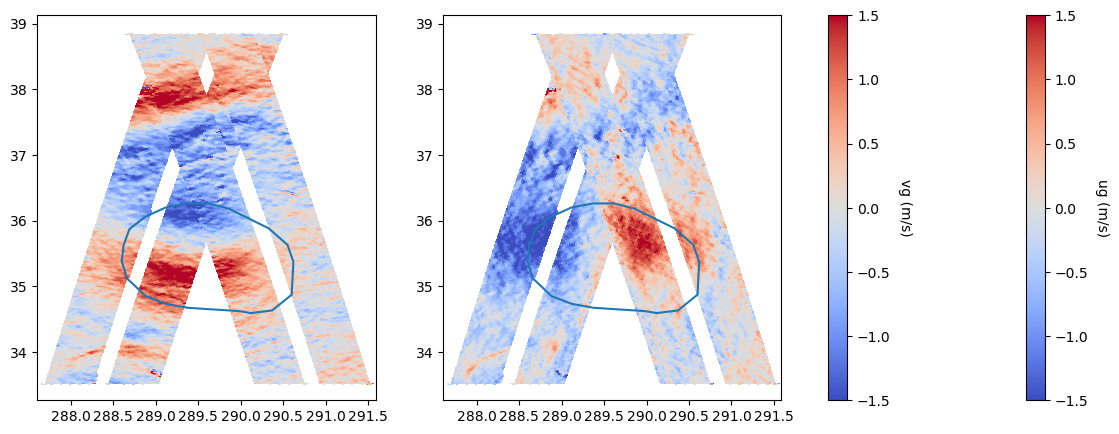

In [34]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ug,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ug2,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[0].plot(contour_lons,contour_lats)

cbar = plt.colorbar(plot,ax=ax)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)


plot = ax[1].pcolormesh(lons,lats,vg,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vg2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
ax[1].plot(contour_lons,contour_lats)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

<Figure size 640x480 with 0 Axes>

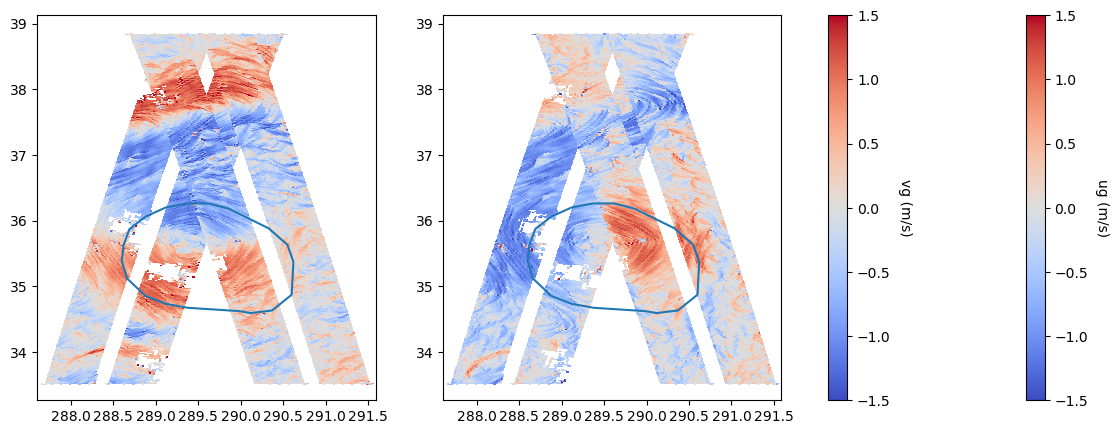

In [35]:
vel=1.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,ucyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,-ucyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
ax[0].plot(contour_lons,contour_lats)

cbar.set_label('ug (m/s)', rotation=270, labelpad=15)

# plot = ax.pcolormesh(grid_x,grid_y,ug2,cmap='coolwarm',vmin=-1,vmax=1)
# ax.plot(contour_lons,contour_lats,zorder=100,c='k',linewidth=2)

plot = ax[1].pcolormesh(lons,lats,vcyclo,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,-vcyclo2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
ax[1].plot(contour_lons,contour_lats)

cbar.set_label('vg (m/s)', rotation=270, labelpad=15)

In [36]:
# Compare geostrophic vorticity with vorticity calculated from cyclogeostrophic currents
def compute_normalized_vorticity_strain(data_array,u,v,wfl):

    lats = jnp.array(data_array.latitude.values)
    lons = jnp.array(data_array.longitude.values)

    dx, dy = jxr.tools.geometry.compute_spatial_step(lats, lons)
    mask = np.zeros_like(u)

    #Smoothing code is under construction here... this snippet of smoothing code written with help of AI (as you can likely tell...)
    #I'm still trying to figure out why just simply running the generic filter on u and v is cutting the swath substantially, whereas this code retains swath width...
    #I'll come back to this, but it does work well for now.
    def direct_2d_swath_smoothing(u_geos_u, lat, lon, window_size=5, angle_tolerance=30):
        """
        Modified version of your original code for 2D smoothing
        """
        # Calculate track direction (same as original)
        dy = np.gradient(lat, axis=0)
        dx = np.gradient(lon, axis=0)
        
        with np.errstate(divide='ignore', invalid='ignore'):
            track_angle = np.arctan2(dy, dx)
            track_angle = np.nan_to_num(track_angle, nan=0.0)
        
        # Use the same window size for both directions
        footprint = np.ones((window_size, window_size), dtype=bool)
        
        def simple_2d_filter(values):
            """Simplified 2D version of your original filter"""
            center_idx = len(values) // 2
            if np.isnan(values[center_idx]):
                return np.nan
            
            # Get center point's track angle
            center_angle = track_angle.flat[center_idx]
            
            # Calculate angular differences
            window_angles = track_angle.flat[:len(values)]
            angle_diffs = np.abs(window_angles - center_angle)
            angle_diffs = np.minimum(angle_diffs, 2*np.pi - angle_diffs)
            
            # Create mask for points along track
            along_track_mask = angle_diffs < np.radians(angle_tolerance)
            valid_mask = ~np.isnan(values)
            
            # Use ALL valid points along track (no distance weighting)
            final_mask = along_track_mask & valid_mask
            
            if np.any(final_mask):
                return np.mean(values[final_mask])  # Simple average
            else:
                return values[center_idx]
    
        smoothed = generic_filter(u_geos_u, simple_2d_filter, footprint=footprint, mode='nearest', cval=np.nan)
        # Apply the filter (this now does 2D smoothing following swath direction)
        return smoothed
   
    # u=generic_filter(u, np.mean, size=[wfl,wfl], mode='nearest')
    # v=generic_filter(v, np.mean, size=[wfl,wfl], mode='nearest')

    u=direct_2d_swath_smoothing(u, lats, lons, window_size=wfl)
    v=direct_2d_swath_smoothing(v, lats, lons, window_size=wfl)

    # Compute derivatives
    dv_dx = jxr.tools.operators.derivative(v, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    du_dy = jxr.tools.operators.derivative(u, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    du_dx = jxr.tools.operators.derivative(u, dx, mask=mask, axis=1, padding="right")  # ∂v/∂x
    dv_dy = jxr.tools.operators.derivative(v, dy, mask=mask, axis=0, padding="right")  # ∂u/∂y

    #Compute coriolis for normalization
    omega = 7.2921159e-05  # angular velocity of the Earth [rad/s]
    fc = 2*omega*np.sin(lats*np.pi/180.)
        
    # avoid zero near equator, bound fc by min val as 1.e-8
    f_coriolis = np.sign(fc)*np.maximum(np.abs(fc), 1.e-8)

    vorticity = dv_dx - du_dy / f_coriolis
    strain= np.sqrt((du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2)
    strain=jnp.array(strain)/f_coriolis 
    OkuboWeiss=(du_dx - dv_dy)**2 + (du_dy + dv_dx) ** 2 - (dv_dx - du_dy) ** 2 #double check and propagate to other scripts
    OkuboWeiss=OkuboWeiss/4

    return vorticity,strain,OkuboWeiss

In [37]:
vort,strain,OkuboWeiss=compute_normalized_vorticity_strain(ds,ug,vg,smoothing_factor)
vort2,strain2,OkuboWeiss2=compute_normalized_vorticity_strain(ds2,ug2,vg2,smoothing_factor) 

In [38]:
strain

Array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [       nan,        nan,        nan, ...,        nan,        nan,
        0.48876324],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan]], dtype=float32)

In [39]:
pixel_num=2 #This number will change per 
vort = remove_swath_edges(vort, edge_pixels=pixel_num)
vort2 = remove_swath_edges(vort2,edge_pixels=pixel_num)

In [40]:
strain = remove_swath_edges(strain,edge_pixels=pixel_num)
strain2 = remove_swath_edges(strain2,edge_pixels=pixel_num)

(33.7, 37.5)

<Figure size 640x480 with 0 Axes>

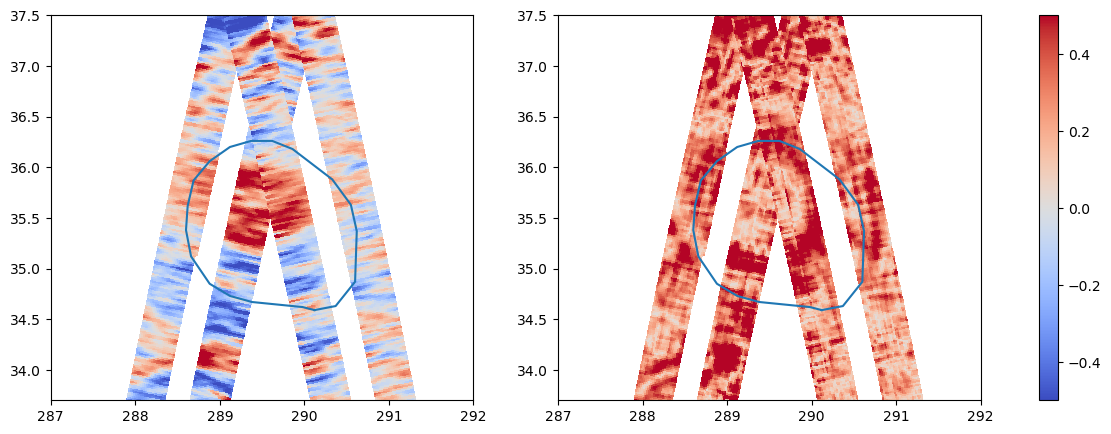

In [41]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)
ax[0].plot(contour_lons,contour_lats)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].plot(contour_lons,contour_lats)

cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

ax[0].set_xlim([287,292])
ax[0].set_ylim([33.7,37.5])
ax[1].set_xlim([287,292])
ax[1].set_ylim([33.7,37.5])

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

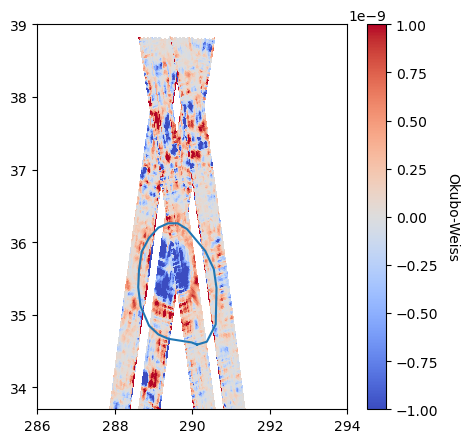

In [42]:
vel=10e-10
plt.clf()

fig,ax=plt.subplots(figsize=(5,5))


plot = plt.pcolormesh(lons,lats,OkuboWeiss,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = plt.pcolormesh(lons2,lats2,OkuboWeiss2,cmap='coolwarm',vmin=-vel,vmax=vel)
plt.plot(contour_lons,contour_lats)

cbar = plt.colorbar(plot)
cbar.set_label('Okubo-Weiss', rotation=270, labelpad=15)
ax.set_xlim([286,294])
ax.set_ylim([33.7,39 ])

In [43]:
vort_cyc,strain_cyc,OkuboWeiss_cyc=compute_normalized_vorticity_strain(ds,ucyclo,vcyclo,smoothing_factor)
vort2_cyc,strain2_cyc,OkuboWeiss_cyc2=compute_normalized_vorticity_strain(ds2,ucyclo2,vcyclo2,smoothing_factor) 

In [44]:
pixel_num=2 #This number will change per 
vort_cyc = remove_swath_edges(vort_cyc, edge_pixels=pixel_num)
vort2_cyc = remove_swath_edges(vort2_cyc,edge_pixels=pixel_num)
strain_cyc = remove_swath_edges(strain_cyc,edge_pixels=pixel_num)
strain2_cyc = remove_swath_edges(strain2_cyc,edge_pixels=pixel_num)

In [45]:
np.shape(strain_cyc)

(318, 69)

In [46]:
ds

<xarray.Dataset> Size: 17MB
Dimensions:                                (num_lines: 318, num_pixels: 69,
                                            num_sides: 2)
Coordinates:
    latitude                               (num_lines, num_pixels) float64 176kB ...
    longitude                              (num_lines, num_pixels) float64 176kB ...
    latitude_nadir                         (num_lines) float64 3kB 33.4 ... 3...
    longitude_nadir                        (num_lines) float64 3kB 288.3 ... ...
Dimensions without coordinates: num_lines, num_pixels, num_sides
Data variables: (12/99)
    time                                   (num_lines, num_pixels) datetime64[ns] 176kB ...
    time_tai                               (num_lines, num_pixels) datetime64[ns] 176kB ...
    ssh_karin                              (num_lines, num_pixels) float64 176kB ...
    ssh_karin_qual                         (num_lines, num_pixels) float64 176kB ...
    ssh_karin_uncert                       (num_lines, num_pixels) float64 176kB ...
    ssha_karin                             (num_lines, num_pixels) float64 176kB ...
    ...                                     ...
    swh_ssb_cor_source_2                   (num_lines, num_pixels) float32 88kB ...
    wind_speed_ssb_cor_source              (num_lines, num_pixels) float32 88kB ...
    wind_speed_ssb_cor_source_2            (num_lines, num_pixels) float32 88kB ...
    volumetric_correlation                 (num_lines, num_pixels) float64 176kB ...
    volumetric_correlation_uncert          (num_lines, num_pixels) float64 176kB ...
    ssha                                   (num_lines, num_pixels) float64 176kB ...
Attributes: (12/62)
    Conventions:                                   CF-1.7
    title:                                         Level 2 Low Rate Sea Surfa...
    institution:                                   CNES
    source:                                        Ka-band radar interferometer
    history:                                       2024-05-10T22:57:22Z : Cre...
    platform:                                      SWOT
    ...                                            ...
    ellipsoid_semi_major_axis:                     6378137.0
    ellipsoid_flattening:                          0.0033528106647474805
    good_ocean_data_percent:                       70.22777425719435
    ssha_variance:                                 0.1290969894990603
    references:                                    V1.2.1
    equator_longitude:                             -77.49

(33.7, 37.5)

<Figure size 640x480 with 0 Axes>

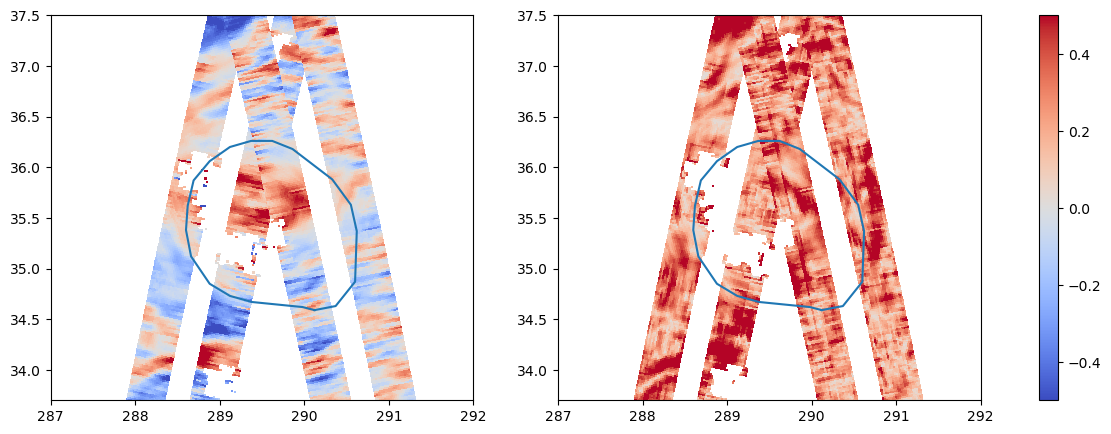

In [47]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(15,5))

plot = ax[0].pcolormesh(lons,lats,vort_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[0].pcolormesh(lons2,lats2,vort2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity/f', rotation=270, labelpad=15)
ax[0].plot(contour_lons,contour_lats)

plot = ax[1].pcolormesh(lons,lats,strain_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
ax[1].plot(contour_lons,contour_lats)

# cbar.set_label('strain/f', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39 ])

ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39 ])

ax[0].set_xlim([287,292])
ax[0].set_ylim([33.7,37.5])
ax[1].set_xlim([287,292])
ax[1].set_ylim([33.7,37.5])

In [48]:
VORT=np.append(np.squeeze(vort),np.squeeze(vort2))
STRAIN=np.append(np.squeeze(strain),np.squeeze(strain2))

GG=VORT;
HH=STRAIN;

STRAIN = STRAIN[~np.isnan(VORT)]
VORT = VORT[~np.isnan(VORT)]

VORT = VORT[~np.isnan(STRAIN)]
STRAIN = STRAIN[~np.isnan(STRAIN)]

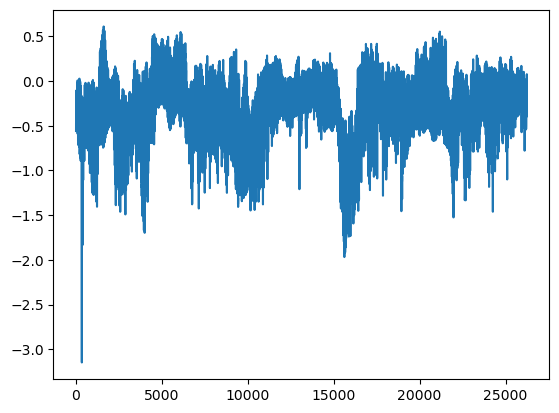

In [49]:
plt.plot(VORT-STRAIN)

In [50]:
VORT_CYC=np.append(np.squeeze(vort_cyc),np.squeeze(vort2_cyc))
STRAIN_CYC=np.append(np.squeeze(strain_cyc),np.squeeze(strain2_cyc))

STRAIN_CYC = STRAIN_CYC[~np.isnan(VORT_CYC)]
VORT_CYC = VORT_CYC[~np.isnan(VORT_CYC)]

VORT_CYC = VORT_CYC[~np.isnan(STRAIN_CYC)]
STRAIN_CYC = STRAIN_CYC[~np.isnan(STRAIN_CYC)]

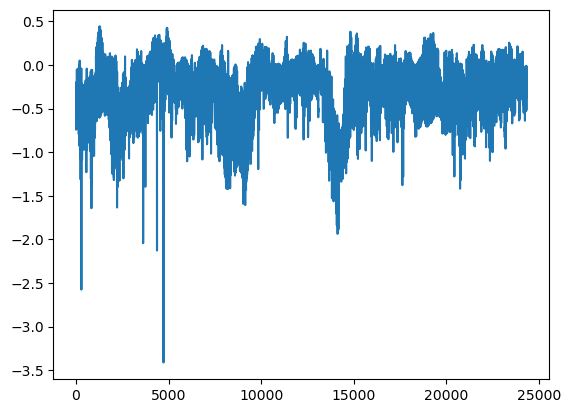

In [51]:
plt.plot(VORT_CYC-STRAIN_CYC)

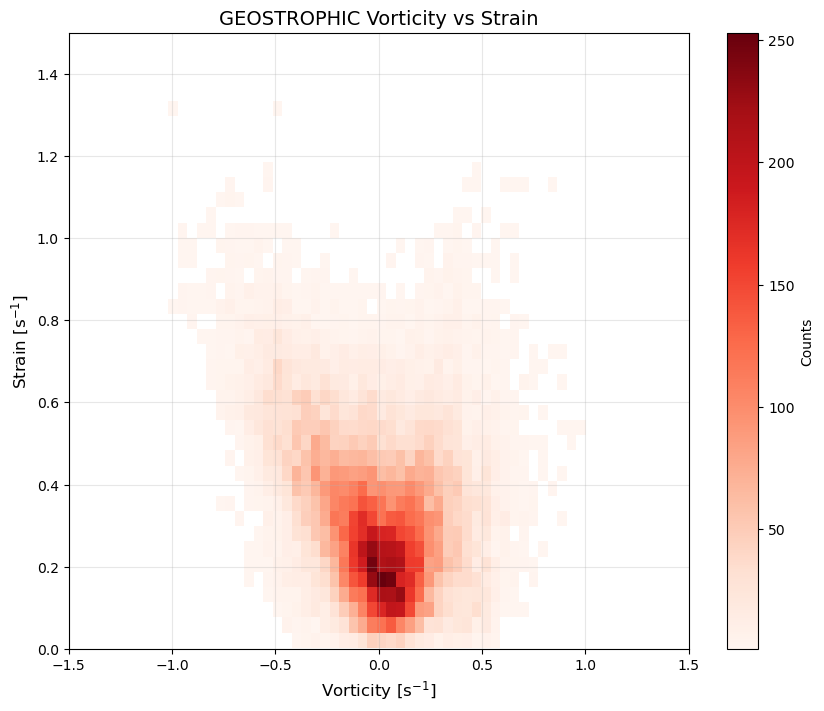

In [52]:
# Set default parameters if not provided
default_kwargs = {
    'bins': (50,50),
    'cmap': 'Reds',
    'density': False
}

# Update defaults with user-provided kwargs
plot_kwargs = default_kwargs.copy()
plot_kwargs.update(default_kwargs)

# Create the 2D histogram
plt.figure(figsize=(10, 8))
h = plt.hist2d(VORT,STRAIN, **plot_kwargs,cmin=0.1)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)

# Add colorbar
cbar = plt.colorbar(h[3], label='Counts')

# Add labels and title
plt.xlabel('Vorticity [s$^{-1}$]', fontsize=12)
plt.ylabel('Strain [s$^{-1}$]', fontsize=12)
plt.title('GEOSTROPHIC Vorticity vs Strain', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

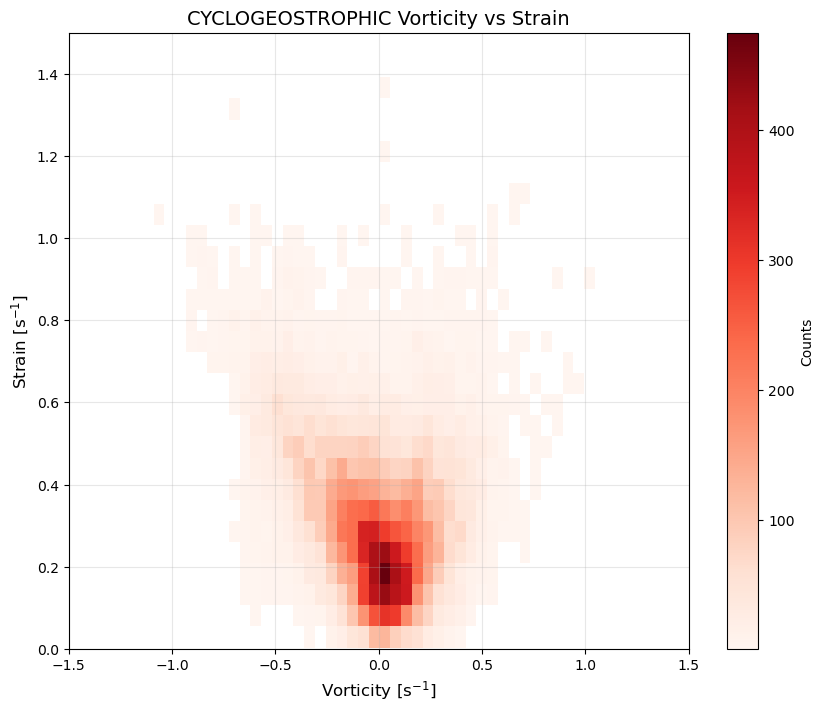

In [53]:
# Set default parameters if not provided
default_kwargs = {
    'bins': (50,50),
    'cmap': 'Reds',
    'density': False
}

# Update defaults with user-provided kwargs
plot_kwargs = default_kwargs.copy()
plot_kwargs.update(default_kwargs)

# Create the 2D histogram
plt.figure(figsize=(10, 8))
h = plt.hist2d(VORT_CYC,STRAIN_CYC, **plot_kwargs,cmin=0.1)
plt.ylim(0,1.5)
plt.xlim(-1.5,1.5)

# Add colorbar
cbar = plt.colorbar(h[3], label='Counts')

# Add labels and title
plt.xlabel('Vorticity [s$^{-1}$]', fontsize=12)
plt.ylabel('Strain [s$^{-1}$]', fontsize=12)
plt.title('CYCLOGEOSTROPHIC Vorticity vs Strain', fontsize=14)

# Add grid for better readability
plt.grid(True, alpha=0.3)

In [54]:
moana_ds = xr.open_dataset('data/moana_Edward_05082024.nc') # should rename this with file extention .ncs
mlon = moana_ds.variables['longitude'] + 360
mlat = moana_ds.variables['latitude'] 
pro = moana_ds.variables['prococcus_moana']
pico = moana_ds.variables['picoeuk_moana'] 
syn = moana_ds.variables['syncoccus_moana'] 
chl= moana_ds.variables['chlor_a'] 
poc= moana_ds.variables['poc'] 

In [55]:
# Let's interpolate MOANA onto SWOT Level-2 grids for each swot dataset
# This will take a long time!
pro1 = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
pro2 = griddata((mlon.values.ravel(),mlat.values.ravel()), pro.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [56]:
pico1 = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
pico2 = griddata((mlon.values.ravel(),mlat.values.ravel()), pico.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [57]:
syn1 = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
syn2 = griddata((mlon.values.ravel(),mlat.values.ravel()), syn.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [58]:
chl1 = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
chl2 = griddata((mlon.values.ravel(),mlat.values.ravel()), chl.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [59]:
PRO=np.append(np.squeeze(pro1),np.squeeze(pro2))
PICO=np.append(np.squeeze(pico1),np.squeeze(pico2))
SYN=np.append(np.squeeze(syn1),np.squeeze(syn2))
CHL=np.append(np.squeeze(chl1),np.squeeze(chl2))
LAT=np.append(np.squeeze(ds.latitude.values),np.squeeze(ds2.latitude.values))
LON=np.append(np.squeeze(ds.longitude.values),np.squeeze(ds2.longitude.values))

In [60]:
CHL_NONAN = CHL[~np.isnan(GG)] #GG is the original VORT array without NaNing... sorry for the bad variable naming
PICO_NONAN = PICO[~np.isnan(GG)]
PRO_NONAN = PRO[~np.isnan(GG)]
SYN_NONAN = SYN[~np.isnan(GG)]
LAT_NONAN=LAT[~np.isnan(GG)]
LON_NONAN=LON[~np.isnan(GG)]

CHL_NONAN = CHL[~np.isnan(HH)] #GG is the original VORT array without NaNing... sorry for the bad variable naming
PICO_NONAN = PICO[~np.isnan(HH)]
PRO_NONAN = PRO[~np.isnan(HH)]
SYN_NONAN = SYN[~np.isnan(HH)]
LAT_NONAN=LAT[~np.isnan(HH)]
LON_NONAN=LON[~np.isnan(HH)]

# plt.scatter(OkuboWeiss,SYN_NONAN)

<Figure size 640x480 with 0 Axes>

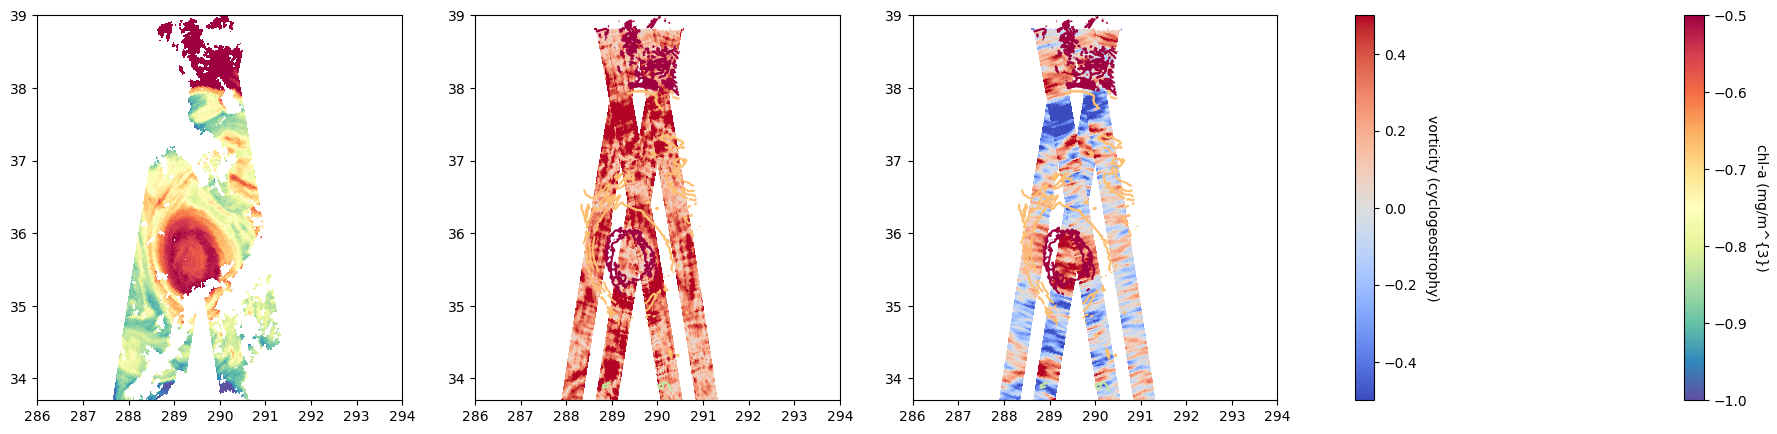

In [61]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,3,figsize=(25,5))

plot = ax[0].pcolormesh(lons,lats,np.log10(chl1),cmap='Spectral_r',vmin=-1,vmax=-0.5)
plot = ax[0].pcolormesh(lons2,lats2,np.log10(chl2),cmap='Spectral_r',vmin=-1,vmax=-0.5)
# plot = ax[0].pcolormesh(lons,lats,pico1,cmap='viridis',vmin=-0,vmax=0.5e4)
# plot = ax[0].pcolormesh(lons2,lats2,pico2,cmap='viridis',vmin=-0,vmax=0.5e4)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('chl-a (mg/m^{3})', rotation=270, labelpad=15)

# ax[0].contour(lons,lats,strain,cmap='Reds',vmin=-0,vmax=0.3)
# ax[0].contour(lons2,lats2,strain2,cmap='Reds',vmin=-0,vmax=0.3)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
# cbar = plt.colorbar(plot,ax=ax)
# cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

ax[1].contour(lons,lats,chl1,10,cmap='Spectral_r',vmin=-0,vmax=0.3)
ax[1].contour(lons2,lats2,chl2,10,cmap='Spectral_r',vmin=-0,vmax=0.3)


plot = ax[2].pcolormesh(lons,lats,vort,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[2].pcolormesh(lons2,lats2,vort2,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[2].set_xlim([286,294])
ax[2].set_ylim([33.7,39])

ax[2].contour(lons,lats,chl1,10,cmap='Spectral_r',vmin=-0,vmax=0.3)
ax[2].contour(lons2,lats2,chl2,10,cmap='Spectral_r',vmin=-0,vmax=0.3)

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

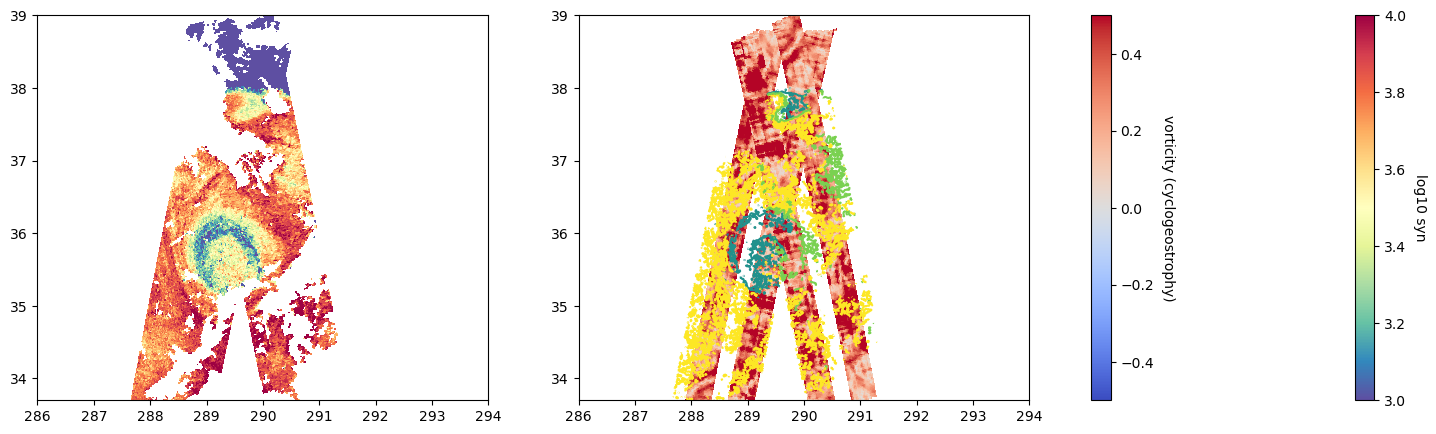

In [62]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

# plot = ax[0].pcolormesh(lons,lats,chl1,cmap='viridis',vmin=-0,vmax=0.3)
# plot = ax[0].pcolormesh(lons2,lats2,chl2,cmap='viridis',vmin=-0,vmax=0.3)
plot = ax[0].pcolormesh(lons,lats,np.log10(syn1),cmap='Spectral_r',vmin=3,vmax=4)
plot = ax[0].pcolormesh(lons2,lats2,np.log10(syn2),cmap='Spectral_r',vmin=3,vmax=4)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('log10 syn', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons,lats,syn1,cmap='viridis',vmin=-0,vmax=0.5e4)

plot = ax[1].pcolormesh(lons2,lats2,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons2,lats2,syn2,cmap='viridis',vmin=-0,vmax=0.5e4)

cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

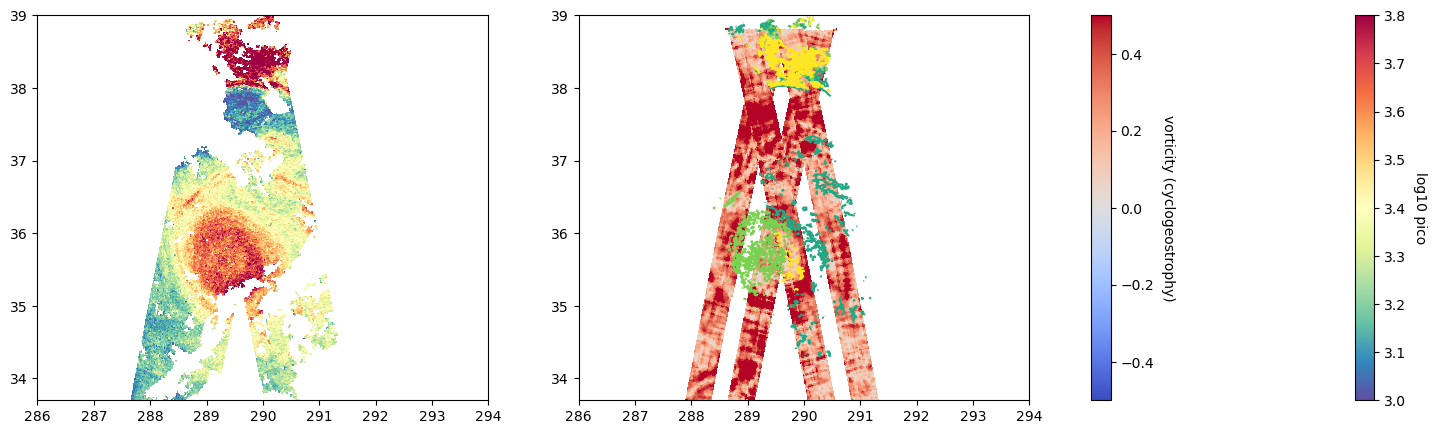

In [63]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

# plot = ax[0].pcolormesh(lons,lats,chl1,cmap='viridis',vmin=-0,vmax=0.3)
# plot = ax[0].pcolormesh(lons2,lats2,chl2,cmap='viridis',vmin=-0,vmax=0.3)
plot = ax[0].pcolormesh(lons,lats,np.log10(pico1),cmap='Spectral_r',vmin=3,vmax=3.8)
plot = ax[0].pcolormesh(lons2,lats2,np.log10(pico2),cmap='Spectral_r',vmin=3,vmax=3.8)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('log10 pico', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons,lats,pico1,cmap='viridis',vmin=-0,vmax=0.5e4)

plot = ax[1].pcolormesh(lons2,lats2,strain2,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons2,lats2,pico2,cmap='viridis',vmin=-0,vmax=0.5e4)

cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

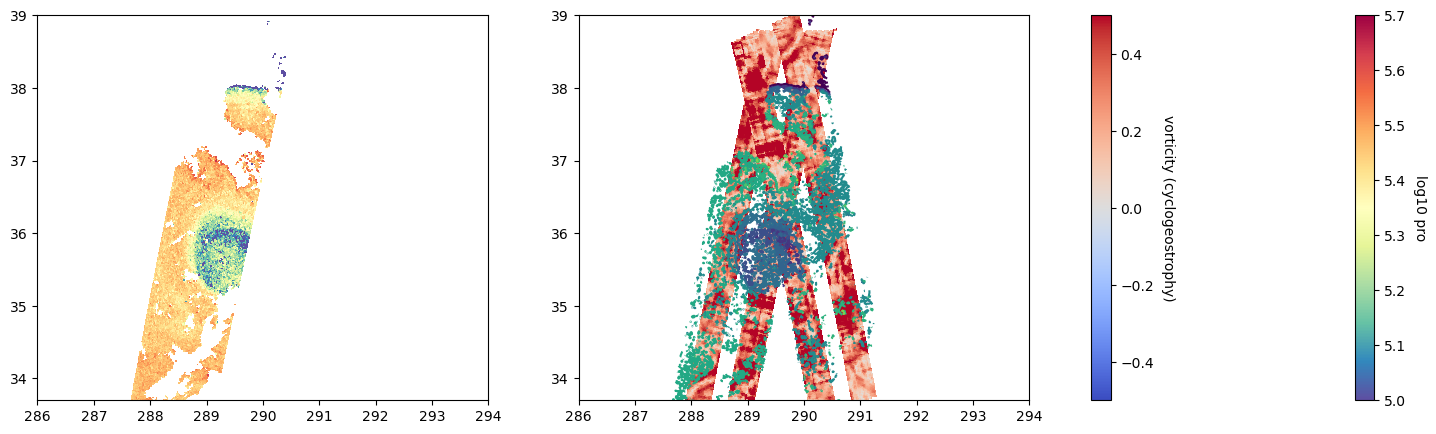

In [64]:
vel=0.5
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

# plot = ax[0].pcolormesh(lons,lats,chl1,cmap='viridis',vmin=-0,vmax=0.3)
# plot = ax[0].pcolormesh(lons2,lats2,chl2,cmap='viridis',vmin=-0,vmax=0.3)
plot = ax[0].pcolormesh(lons,lats,np.log10(pro1),cmap='Spectral_r',vmin=5,vmax=5.7)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('log10 pro', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons,lats,pro1,cmap='viridis',vmin=-0,vmax=0.5e6)

plot = ax[1].pcolormesh(lons2,lats2,strain,cmap='coolwarm',vmin=-vel,vmax=vel)
ax[1].contour(lons2,lats2,pro2,cmap='viridis',vmin=-0,vmax=0.5e6)

cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

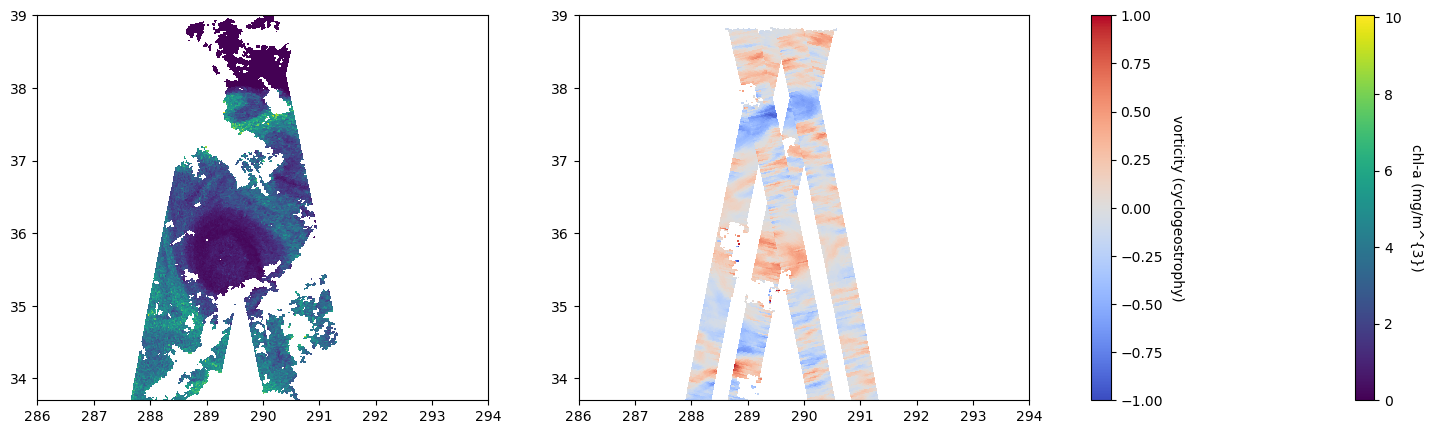

In [65]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

# plot = ax[0].pcolormesh(lons,lats,chl1,cmap='viridis',vmin=-0,vmax=0.3)
# plot = ax[0].pcolormesh(lons2,lats2,chl2,cmap='viridis',vmin=-0,vmax=0.3)
plot = ax[0].pcolormesh(lons,lats,syn1/pico1,cmap='viridis')#,vmin=-0,vmax=0.5e4)
plot = ax[0].pcolormesh(lons2,lats2,syn2/pico2,cmap='viridis')#,vmin=-0,vmax=0.5e4)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('chl-a (mg/m^{3})', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,vort_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,vort2_cyc,cmap='coolwarm',vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity (cyclogeostrophy)', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

In [66]:
max_lat=37 #cut off gulf stream
# mask = (lons >= min_lon) & (lons <= max_lon) & (lats >= min_lat) & (lats <= max_lat)
mask = (LAT_NONAN <= max_lat)
CHL_CROP=CHL_NONAN[mask]
VORT_CROP=VORT[mask]
STRAIN_CROP=STRAIN[mask]
PICO_CROP=PICO_NONAN[mask]
PRO_CROP=PRO_NONAN[mask]
SYN_CROP=SYN_NONAN[mask]

In [67]:
PACE_NAN_IDX=CHL_CROP

In [68]:
CHL_CROP=CHL_CROP[~np.isnan(PACE_NAN_IDX)]
VORT_CROP=VORT_CROP[~np.isnan(PACE_NAN_IDX)]
STRAIN_CROP=STRAIN_CROP[~np.isnan(PACE_NAN_IDX)]
PICO_CROP=PICO_CROP[~np.isnan(PACE_NAN_IDX)]
PRO_CROP=PRO_CROP[~np.isnan(PACE_NAN_IDX)]
SYN_CROP=SYN_CROP[~np.isnan(PACE_NAN_IDX)]

(-2.0, 2.0)

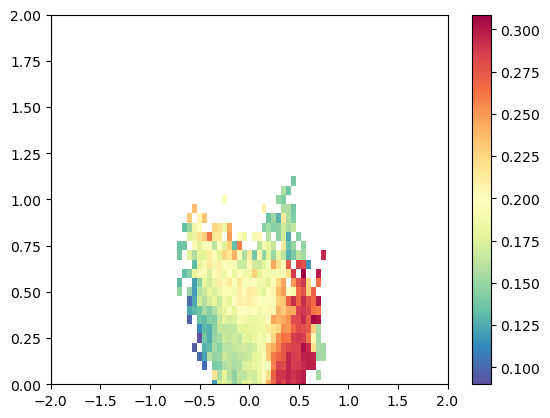

In [69]:
statistic='mean'
stat_chl='mean'
resolution=0.05
vort_reg = np.arange(-2.1, 2, resolution)
strain_reg = np.arange(0, 2, resolution)
chl_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,CHL_CROP, statistic=stat_chl, bins=[vort_reg, strain_reg])
pico_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,PICO_CROP, statistic=statistic, bins=[vort_reg, strain_reg])
pro_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,PRO_CROP, statistic=statistic, bins=[vort_reg, strain_reg])
syn_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,SYN_CROP, statistic=statistic, bins=[vort_reg, strain_reg])
pro_syn_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,PRO_CROP/SYN_CROP, statistic=statistic, bins=[vort_reg, strain_reg])
pro_pico_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,PRO_CROP/PICO_CROP, statistic=statistic, bins=[vort_reg, strain_reg])

plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],chl_vs_space.T,cmap='Spectral_r')
plt.colorbar(plot)
plt.ylim(0,2)
plt.xlim(-2,2)

In [70]:
# resolution=0.1
# vort_reg = np.arange(-2.1, 2, resolution)
# strain_reg = np.arange(0, 2, resolution)
# vort_reg_mesh, strain_reg_mesh = np.meshgrid(vort_reg, strain_reg)
# chl_vs_space = griddata((VORT_CROP,STRAIN_CROP), CHL_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
# pico_vs_space = griddata((VORT_CROP,STRAIN_CROP), PICO_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
# pro_vs_space = griddata((VORT_CROP,STRAIN_CROP), PRO_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')
# syn_vs_space = griddata((VORT_CROP,STRAIN_CROP), SYN_CROP, (vort_reg_mesh,strain_reg_mesh), method='linear')

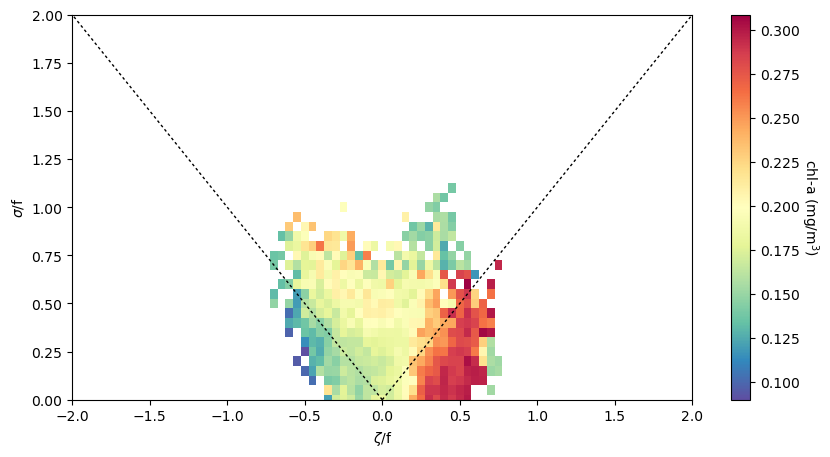

In [71]:
fig=plt.subplots(figsize=(10,5))
# plot=plt.scatter(vort_reg_mesh,strain_reg_mesh,c=chl_vs_space,cmap='Spectral_r',vmax=0.3)
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],chl_vs_space.T,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')
cbar.set_label('chl-a (mg/m$^{3}$)', rotation=270, labelpad=15)

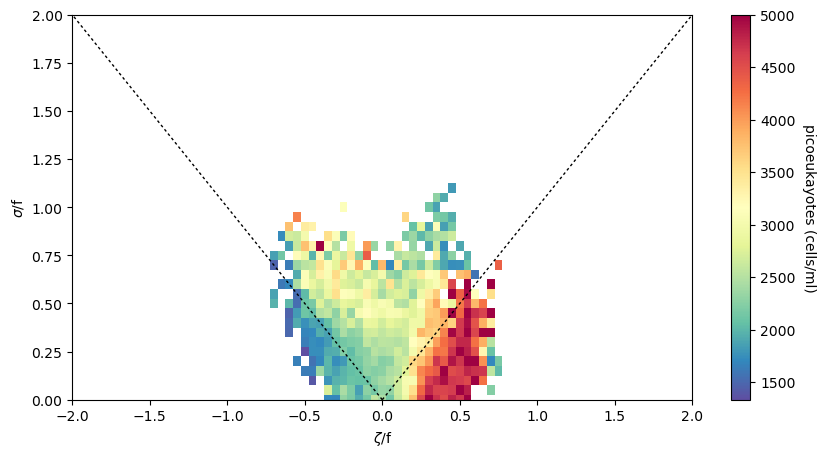

In [72]:
fig=plt.subplots(figsize=(10,5))
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pico_vs_space,cmap='Spectral_r')
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],pico_vs_space.T,cmap='Spectral_r',vmax=5000)
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')
cbar.set_label('picoeukayotes (cells/ml)', rotation=270, labelpad=15)

Text(0, 0.5, '$\\sigma$/f')

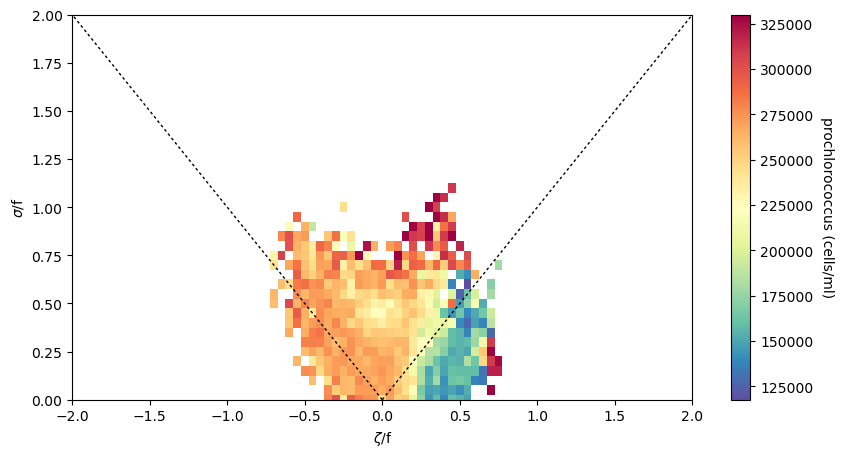

In [73]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],pro_vs_space.T,cmap='Spectral_r',vmax=330000)
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space,cmap='Spectral_r')
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
cbar.set_label('prochlorococcus (cells/ml)', rotation=270, labelpad=15)
plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

Text(0, 0.5, '$\\sigma$/f')

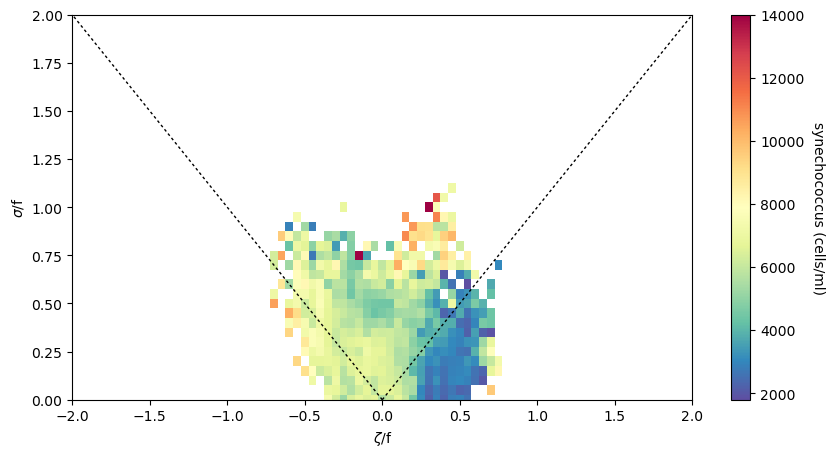

In [74]:
fig=plt.subplots(figsize=(10,5))
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,syn_vs_space,cmap='Spectral_r',vmax=12000)
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],syn_vs_space.T,cmap='Spectral_r',vmax=14000)
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
cbar.set_label('synechococcus (cells/ml)', rotation=270, labelpad=15)

plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

Text(0, 0.5, '$\\sigma$/f')

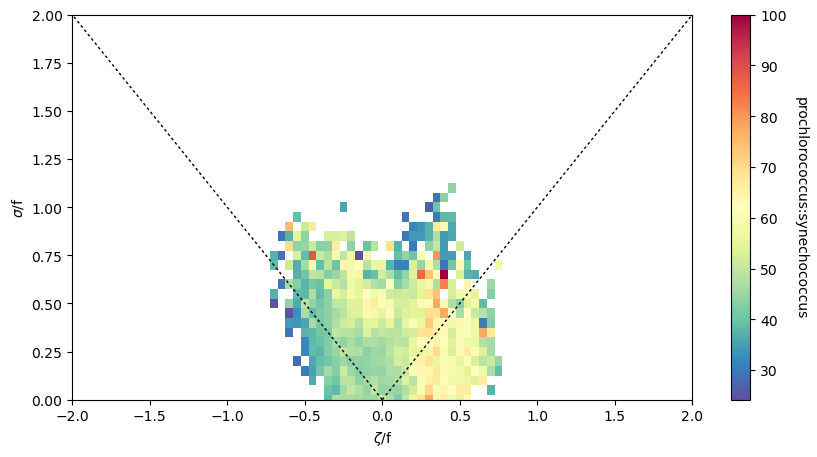

In [75]:
fig=plt.subplots(figsize=(10,5))
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_syn_vs_space,cmap='Spectral_r',vmax=50)
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],pro_syn_vs_space.T,cmap='Spectral_r',vmax=100)
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
cbar.set_label('prochlorococcus:synechococcus', rotation=270, labelpad=15)

plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

Text(0, 0.5, '$\\sigma$/f')

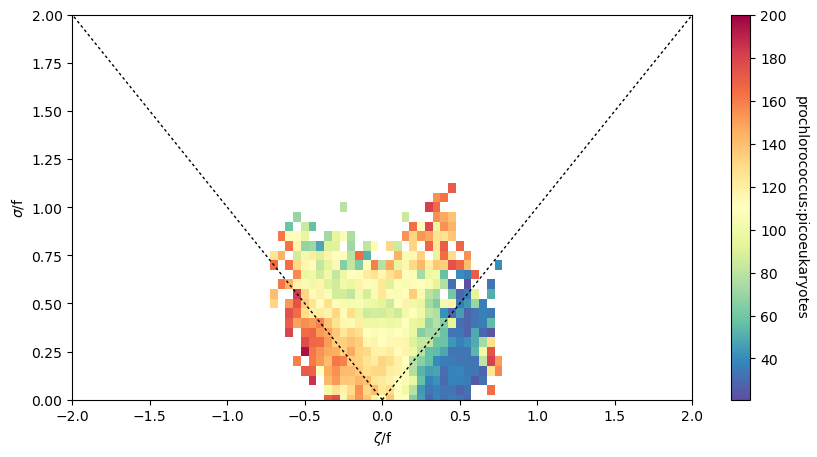

In [76]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],pro_pico_vs_space.T,cmap='Spectral_r',vmax=200)
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space/pico_vs_space,cmap='Spectral_r',vmin=50,vmax=250)
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
cbar.set_label('prochlorococcus:picoeukaryotes', rotation=270, labelpad=15)
plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

### Now, do SST

In [77]:
pacedate

'2024-05-08'

In [78]:
tspan = (pacedate,pacedate) 
bbox = (lonmin, latmin, lonmax, latmax)
# MODIST_L2_SST i really want that one but its not working
results = earthaccess.search_data(
    short_name='L3S_LEO_DY-STAR-v2.81',
    bounding_box=bbox,
    temporal=tspan,
)

#AVHRR_SST_METOP_B-OSISAF-L2P-v1.0
#AVHRRF_MB-STAR-L2P-v2.80
#AVHRRF_MC-STAR-L2P-v2.80
#MUR-JPL-L4-GLOB-v4.1
#AVHRR_SST_METOP_B_GLB-OSISAF-L3C-v1.0
# AVHRR_SST_METOP_B_GLB-OSISAF-L3C-v1.0 REALLY BAD

In [79]:
# paths[1]

In [80]:
paths = earthaccess.open(results) #'streaming' data

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [81]:
datatree = xr.open_datatree(paths[0]) 

# Merge
dsmerge = xr.merge(datatree.to_dict().values())
dsmerge = dsmerge.set_coords(("lon", "lat"))

# Crop to bounding box
llon, llat, rlon, ulat = bbox

# If lat is descending, swap slice
if dsmerge.lat[0] > dsmerge.lat[-1]:
    cropped = dsmerge.sel(lon=slice(llon, rlon), lat=slice(ulat, llat))
else:
    cropped = dsmerge.sel(lon=slice(llon, rlon), lat=slice(llat, ulat))

dataset=cropped

del cropped
del datatree
del dsmerge

Text(0.5, 0, 'Longitude (E$^{\\circ}$)')

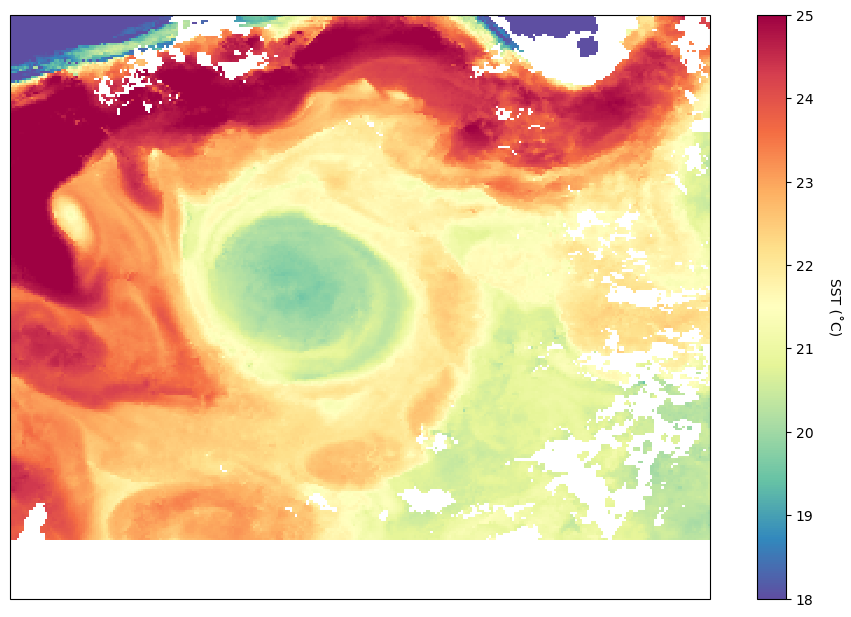

In [82]:
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(nrows=3, ncols=3)
ax0 = fig.add_subplot(gs[:-1, :],projection=ccrs.PlateCarree())

plt.subplots_adjust(hspace=0.4)
#plot=ax0.pcolormesh(dataset['lon'],dataset['lat'],np.squeeze(dataset['analysed_sst'])-273.15,cmap='Spectral_r',vmin=18, vmax=25)
plot=ax0.pcolormesh(dataset['lon'],dataset['lat'],np.squeeze(dataset['sea_surface_temperature'])-273.15,cmap='Spectral_r',vmin=18, vmax=25)

cbar = plt.colorbar(plot,ax=ax0)
cbar.set_label('SST (˚C)', rotation=270, labelpad=20)

#edward
ax0.set_ylim([33,38])
ax0.set_xlim([-73,-67])

#eddy16
# ax.set_ylim([34.5,39.5])
# ax.set_xlim([-54,-48])

# ax.set_ylim([34.5,39.5])
# ax.set_xlim([-54,-48])

ax0.set_ylabel('Latitude (N$^{\circ}$)')
ax0.set_xlabel('Longitude (E$^{\circ}$)')

Text(0.5, 0, 'Longitude (E$^{\\circ}$)')

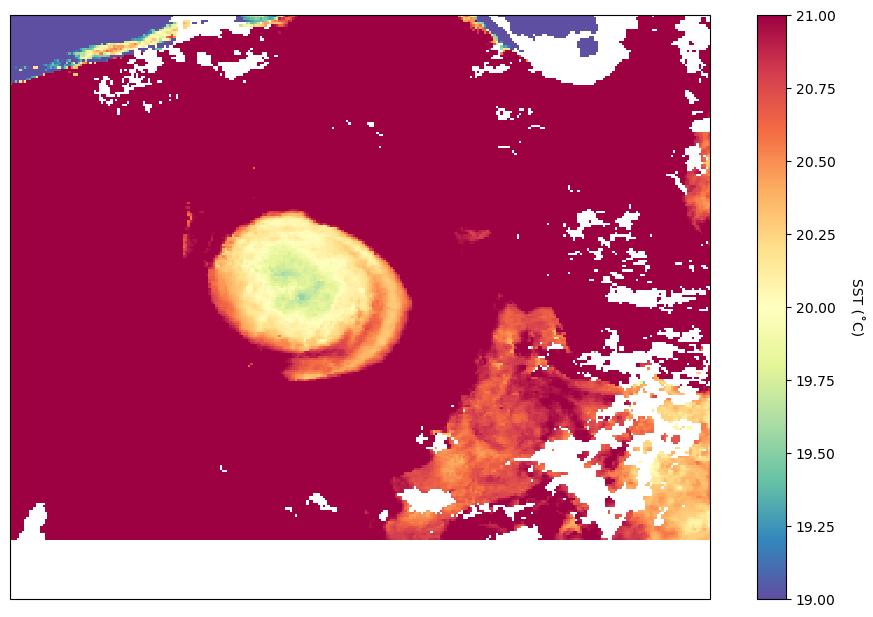

In [83]:
fig = plt.figure(figsize=(12, 12))
gs = fig.add_gridspec(nrows=3, ncols=3)
ax0 = fig.add_subplot(gs[:-1, :],projection=ccrs.PlateCarree())

plt.subplots_adjust(hspace=0.4)
#plot=ax0.pcolormesh(dataset['lon'],dataset['lat'],np.squeeze(dataset['analysed_sst'])-273.15,cmap='Spectral_r',vmin=18, vmax=25)
plot=ax0.pcolormesh(dataset['lon'],dataset['lat'],np.squeeze(dataset['sea_surface_temperature'])-273.15,cmap='Spectral_r',vmin=19, vmax=21)

cbar = plt.colorbar(plot,ax=ax0)
cbar.set_label('SST (˚C)', rotation=270, labelpad=20)

#edward
ax0.set_ylim([33,38])
ax0.set_xlim([-73,-67])

#eddy16
# ax.set_ylim([34.5,39.5])
# ax.set_xlim([-54,-48])

# ax.set_ylim([34.5,39.5])
# ax.set_xlim([-54,-48])

ax0.set_ylabel('Latitude (N$^{\circ}$)')
ax0.set_xlabel('Longitude (E$^{\circ}$)')

### Regrid SST

In [84]:
sst=dataset['sea_surface_temperature']-273.15

In [85]:
Lon2D, Lat2D = np.meshgrid(dataset['lon']+360, dataset['lat'])

In [86]:
sst1 = griddata((Lon2D.ravel(),Lat2D.ravel()), sst.values.ravel(), (ds.longitude.values, ds.latitude.values), method='linear')
sst2 = griddata((Lon2D.ravel(),Lat2D.ravel()), sst.values.ravel(), (ds2.longitude.values, ds2.latitude.values), method='linear')

In [87]:
SST=np.append(np.squeeze(sst1),np.squeeze(sst2))

SST_NONAN = SST[~np.isnan(GG)] #GG is the original VORT array without NaNing... sorry for the bad variable naming
SST_NONAN = SST[~np.isnan(HH)] #GG is the original VORT array without NaNing... sorry for the bad variable naming

# plt.scatter(OkuboWeiss,SYN_NONAN)

In [88]:
%pip install cmocean
import cmocean

  Using cached cmocean-4.0.3-py3-none-any.whl.metadata (4.2 kB)
Using cached cmocean-4.0.3-py3-none-any.whl (421 kB)
Note: you may need to restart the kernel to use updated packages.


(33.7, 39.0)

<Figure size 640x480 with 0 Axes>

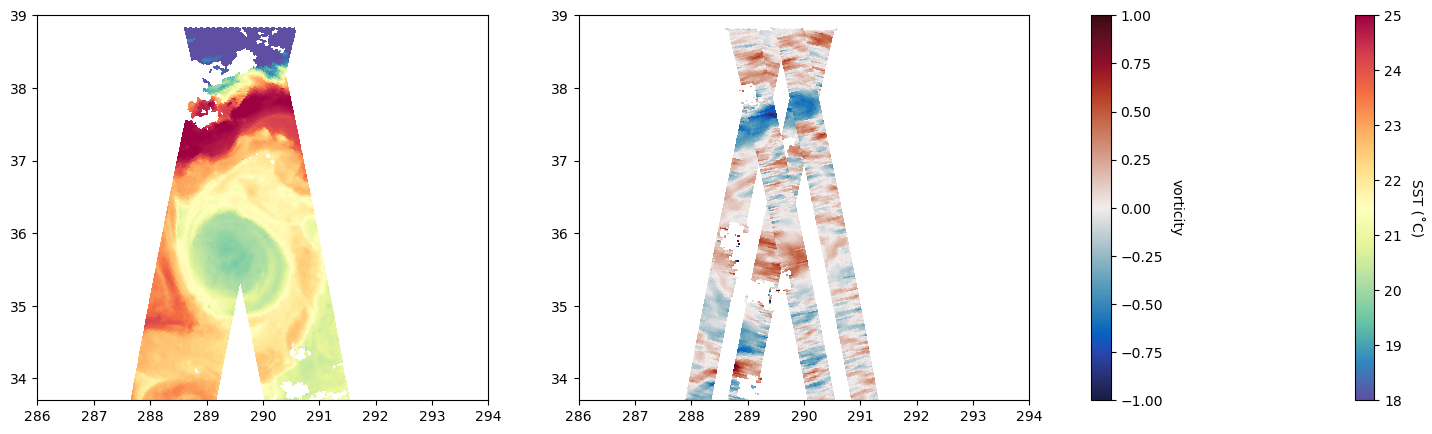

In [89]:
vel=1
plt.clf()

fig,ax=plt.subplots(1,2,figsize=(20,5))

plot = ax[0].pcolormesh(lons,lats,sst1,cmap='Spectral_r',vmin=18,vmax=25)
plot = ax[0].pcolormesh(lons2,lats2,sst2,cmap='Spectral_r',vmin=18,vmax=25)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('SST (˚C)', rotation=270, labelpad=15)

plot = ax[1].pcolormesh(lons,lats,vort_cyc,cmap=cmocean.cm.balance,vmin=-vel,vmax=vel)
plot = ax[1].pcolormesh(lons2,lats2,vort2_cyc,cmap=cmocean.cm.balance,vmin=-vel,vmax=vel)
cbar = plt.colorbar(plot,ax=ax)
cbar.set_label('vorticity', rotation=270, labelpad=15)
ax[0].set_xlim([286,294])
ax[0].set_ylim([33.7,39])
ax[1].set_xlim([286,294])
ax[1].set_ylim([33.7,39])

In [90]:
SST_CROP=SST_NONAN[mask]
SST_NONAN_IDX=SST_CROP
SST_CROP=SST_CROP[~np.isnan(SST_NONAN_IDX)]

In [91]:
VORT_CROP=VORT[mask]
STRAIN_CROP=STRAIN[mask]

In [92]:
VORT_CROP=VORT_CROP[~np.isnan(SST_NONAN_IDX)]
STRAIN_CROP=STRAIN_CROP[~np.isnan(SST_NONAN_IDX)]

In [93]:
SST_CROP

array([22.28442557, 22.47538886, 22.49295415, ..., 21.17143534,
       21.18509564, 21.34014261], shape=(16962,))

In [94]:
statistic='mean'
resolution=0.1
vort_reg = np.arange(-2.1, 2, resolution)
strain_reg = np.arange(0, 2, resolution)
sst_vs_space, vort_bin, strain_bin, N = binned_statistic_2d(VORT_CROP,STRAIN_CROP,SST_CROP, statistic=statistic, bins=[vort_reg, strain_reg])

Text(0, 0.5, '$\\sigma$/f')

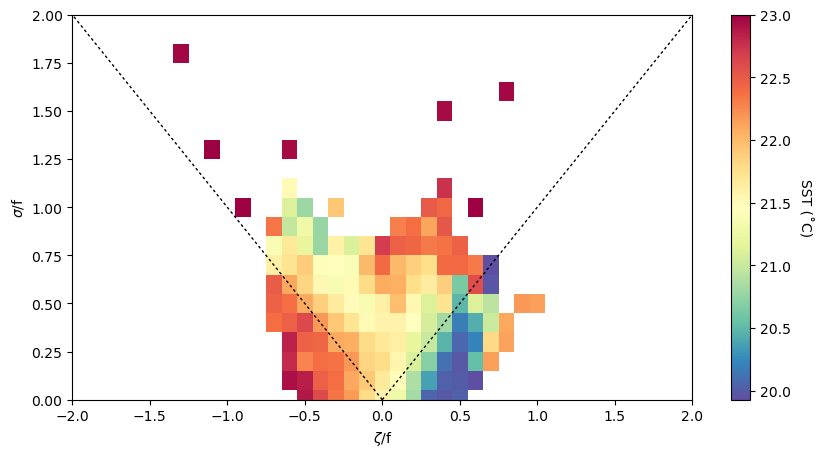

In [95]:
fig=plt.subplots(figsize=(10,5))
plot=plt.pcolormesh(vort_bin[0:-1],strain_bin[0:-1],sst_vs_space.T,cmap='Spectral_r',vmax=23)
# plot=plt.pcolor(vort_reg_mesh,strain_reg_mesh,pro_vs_space/pico_vs_space,cmap='Spectral_r',vmin=50,vmax=250)
plt.plot([0,3], [0, 3], 'k-', lw=1,dashes=[2, 2])
plt.plot([0,-3], [0, 3], 'k', lw=1,dashes=[2, 2])
cbar = plt.colorbar(plot)
cbar.set_label('SST (˚C)', rotation=270, labelpad=15)
plt.ylim(0,2)
plt.xlim(-2,2)
plt.xlabel('$\zeta$/f')
plt.ylabel('$\sigma$/f')

ValueError: x and y must be the same size

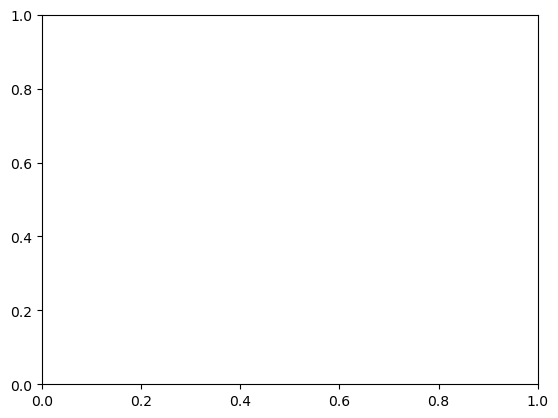

In [96]:
plt.scatter(chl_vs_space,sst_vs_space)

In [ ]:
plt.scatter(pro_vs_space,sst_vs_space)
plt.title('SST vs. pro')

In [ ]:
plt.scatter(pico_vs_space,sst_vs_space)
plt.title('SST vs. PICO')

In [ ]:
plt.scatter(syn_vs_space,sst_vs_space)
plt.title('SST vs. SYN')

In [ ]:
plt.scatter(pro_syn_vs_space,sst_vs_space)
plt.title('SST vs. PRO:SYN')

In [ ]:
plt.scatter(pro_pico_vs_space,sst_vs_space)
plt.title('SST vs. PRO:PICO')

In [ ]:
plt.scatter(pro_vs_space,chl_vs_space)
plt.title('CHL vs. pro')

In [ ]:
sstcompare=SST_NONAN_IDX[~np.isnan(PACE_NAN_IDX)]
plt.scatter(CHL_CROP,sstcompare)
plt.title('SST VS CHL')

In [ ]:
plt.scatter(SYN_CROP,sstcompare)
plt.title('SST VS SYN')

In [ ]:
plt.scatter(PRO_CROP,sstcompare)
plt.title('SST VS PRO')

In [ ]:
plt.scatter(PICO_CROP,sstcompare)
plt.title('SST VS PICO')

In [ ]:
plt.scatter(sst1,chl1,c=OkuboWeiss,cmap='Spectral',vmin=0.1e-10,vmax=5e-10)
plt.scatter(sst2,chl2,c=OkuboWeiss2,cmap='Spectral',vmin=0.1e-10,vmax=5e-10)


In [ ]:
plt.scatter(sst1,chl1,c=strain,cmap='Spectral',vmin=0,vmax=0.5)
plt.scatter(sst2,chl2,c=strain2,cmap='Spectral',vmin=0,vmax=0.5)


In [ ]:
plt.scatter(sst1,chl1,c=vort,cmap='Spectral',vmin=0,vmax=0.5)
plt.scatter(sst2,chl2,c=vort2,cmap='Spectral',vmin=0,vmax=0.5)


In [ ]:
plt.scatter(sst1,OkuboWeiss,c=chl1,cmap='Spectral')
plt.scatter(sst2,OkuboWeiss2,c=chl2,cmap='Spectral')


### NEUROST